In [ ]:
# Import & Settings
import scipy.io
import json
import numpy as np
import pathlib
import os
import platform
import matplotlib.pyplot as plt
import cv2

DEVICE = 'cuda' if (platform.system() == "Windows") else 'cpu'

## Data Preparation

In [2]:
def load_matlab_data(mat_file):
    """Load data from a .mat file and store it in a dictionary."""
    file = pathlib.Path(mat_file)
    mat = scipy.io.loadmat(file)
    return mat
mat = load_matlab_data(r"C:\Users\tkpp2\Documents\FISH-ML2\assets\EXP251009COL\matlabEXP251009COL_251022_1739_all_track.mat")

In [3]:
all_keys = mat.keys()
print("Total keys:", len(all_keys))
keys = []
for k in all_keys:
    if k.startswith("Track"):
        keys.append(k)
        print(k)

Total keys: 17
Track251009COLA01
Track251009COLA02
Track251009COLA03
Track251009COLB01
Track251009COLB02
Track251009COLB03
Track251009COLC01
Track251009COLC02
Track251009COLD01
Track251009COLD02
Track251009COLE01
Track251009COLE02
Track251009COLF01
Track251009COLF02


In [4]:
data = mat["Track251009COLA01"]
data.shape

(1, 5)

In [5]:
print(f"segmented frames cnt: {data.shape[1]}") # num of frames 
all_frames = data[0]

segmented frames cnt: 5


In [6]:
def convert(all_frames):
    converted: list[dict] = []
    for i in range(all_frames.shape[0]):
        cur = dict()
        # use try catch to avoid error on edge cases
        try:
            for j in range(100):
                cur[j] = all_frames[i][0,0][j][0] 
        except IndexError:
            pass
        converted.append(cur)
    return converted

In [7]:
def getCells(singleFrame, cellsLoc=2, cellsInfoIndex=12):
    ttlCellsInFrame = singleFrame[cellsLoc].shape[0]
    cells = []
    for i in range(ttlCellsInFrame):
        info = []
        cell = singleFrame[cellsLoc][i][0,0]
        for j in range(cellsInfoIndex):
            info.append(cell[j])
        cells.append(info)
    return cells

In [8]:
all_frames_converted = convert(all_frames)
frame_no_1 = all_frames_converted[0]

In [9]:
all_cells_in_frame_no_1 = getCells(frame_no_1)

### Data Augmentation

#### Image Dilation & Rotation

In [10]:
def imgDilation(cells):
    """Converts the cells into a binary matrix and then dilates it to get the edges of the cells."""
    dilated_matrix = scipy.ndimage.binary_dilation(cells)
    edge_matrix = dilated_matrix - cells
    return edge_matrix

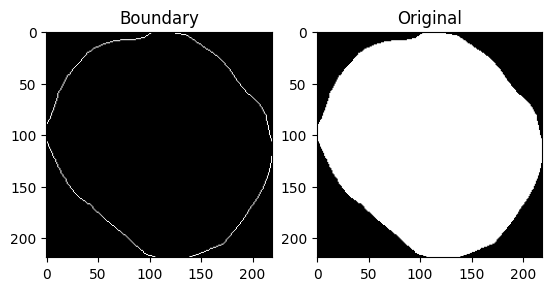

In [11]:
np.set_printoptions(threshold = np.inf)

boundary = plt.subplot(1, 2, 1)
boundary.set_title('Boundary')
boundary_matrix = imgDilation(all_cells_in_frame_no_1[0][0])
# print(f"bondary_matrix_first_col: \n{boundary_matrix[:, 0]}")
boundary.imshow(boundary_matrix, cmap='gray')
original = plt.subplot(1, 2, 2)
original.imshow(all_cells_in_frame_no_1[0][0], cmap='gray')
original.set_title('Original')
plt.show()

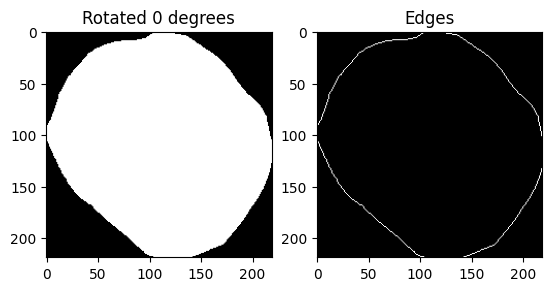

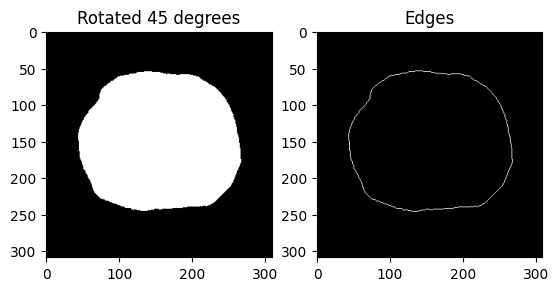

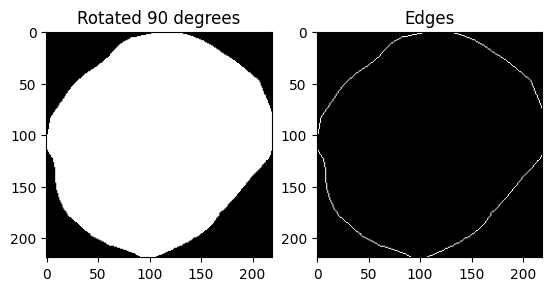

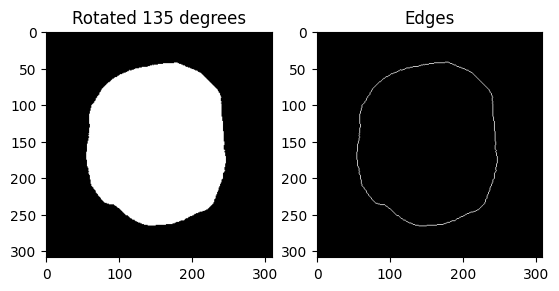

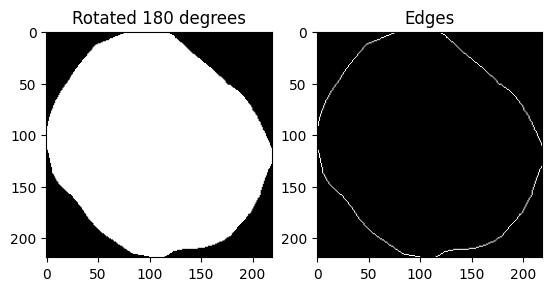

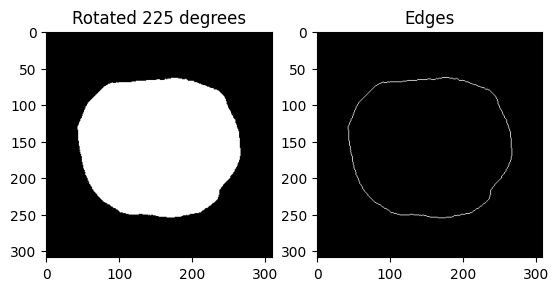

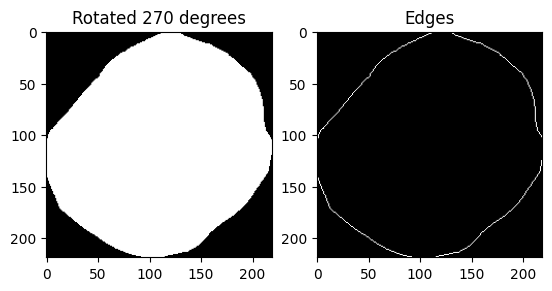

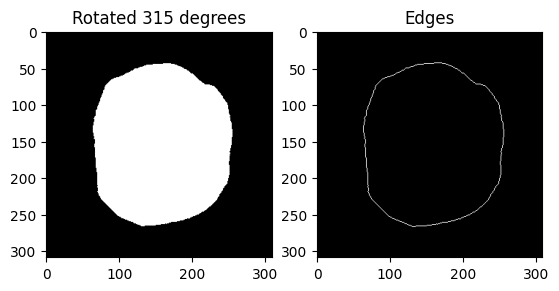

In [12]:
def imgRotation(cell, a):
    (h, w) = cell.shape[:2]
    angle = a
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    # When rotating, the image corners might move outside of the frame
    # To fit the whole rotated image, calculate the new width and height
    cos = np.abs(M[0, 0])
    sin = np.abs(M[0, 1])
    # New width and height
    new_w = int((h * sin) + (w * cos))
    new_h = int((h * cos) + (w * sin))
    # Adjust the rotation matrix to take into account translation
    M[0, 2] += (new_w / 2) - center[0]
    M[1, 2] += (new_h / 2) - center[1]
    rotated_image_matrix = cv2.warpAffine(cell, M, (new_w, new_h))
    return rotated_image_matrix

# Test and rotate the image by some degrees
for i in range(0, 360, 45):
    rotated = imgRotation(all_cells_in_frame_no_1[0][0], i)
    edged = imgDilation(rotated)
    rotated_plot = plt.subplot(1, 2, 1)
    rotated_plot.set_title(f'Rotated {i} degrees')
    rotated_plot.imshow(rotated, cmap='gray')
    edged_plot = plt.subplot(1, 2, 2)
    edged_plot.set_title('Edges')
    edged_plot.imshow(edged, cmap='gray')
    plt.show()

#### Adding Blur, Noise & Glare

In [13]:
from skimage.util import random_noise

def add_gaussian_noise(img, var=0.005):
    """Add Gaussian noise; var ≈ 0.001–0.02. Returns uint8."""
    img_f = img.astype(np.float32)
    rng = img_f.max() - img_f.min()
    img_norm = (img_f - img_f.min()) / (rng if rng > 0 else 1)
    noisy = random_noise(img_norm, mode='gaussian', var=var)
    return (noisy * 255).astype(np.uint8)

def add_salt_pepper(img, amount=0.01, salt_vs_pepper=0.5):
    """Add salt & pepper noise; amount ≈ 0.001–0.05. Returns uint8."""
    img_f = img.astype(np.float32)
    rng = img_f.max() - img_f.min()
    img_norm = (img_f - img_f.min()) / (rng if rng > 0 else 1)
    noisy = random_noise(img_norm, mode='s&p', amount=amount, salt_vs_pepper=salt_vs_pepper)
    return (noisy * 255).astype(np.uint8)

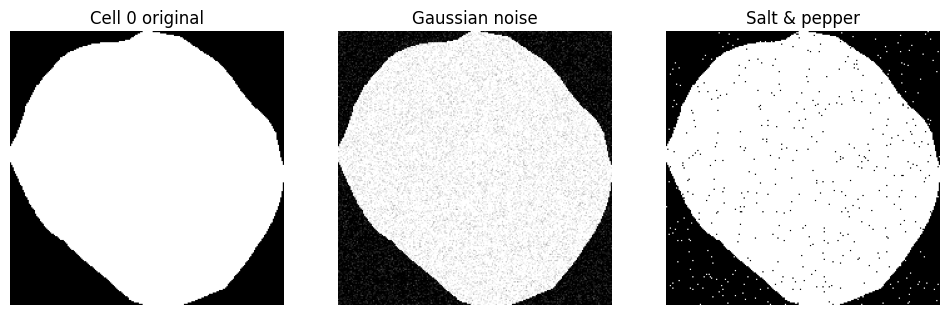

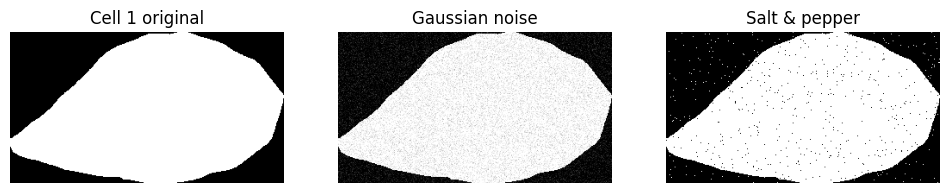

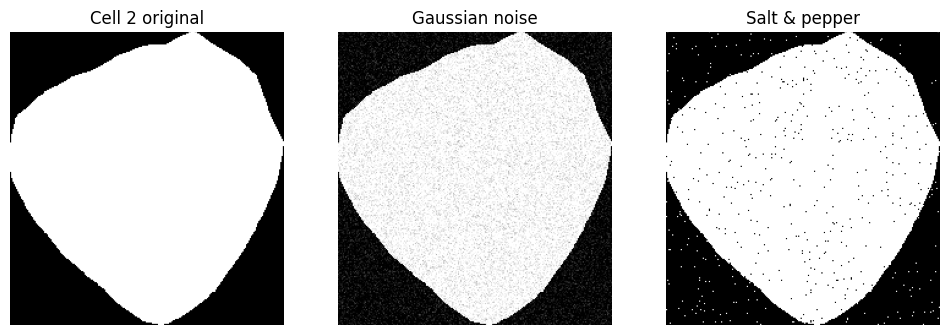

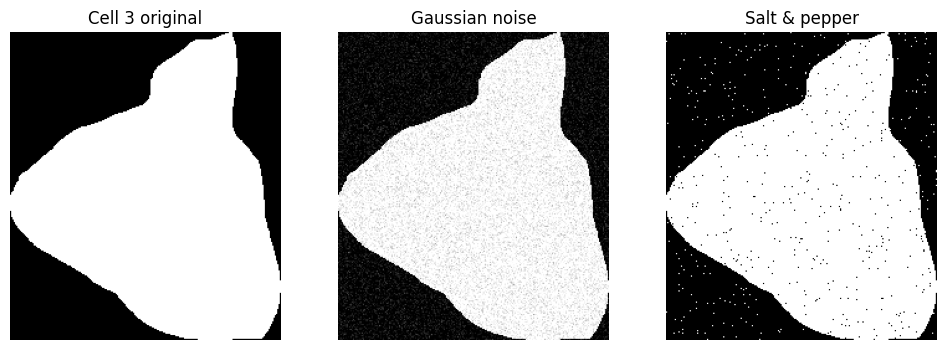

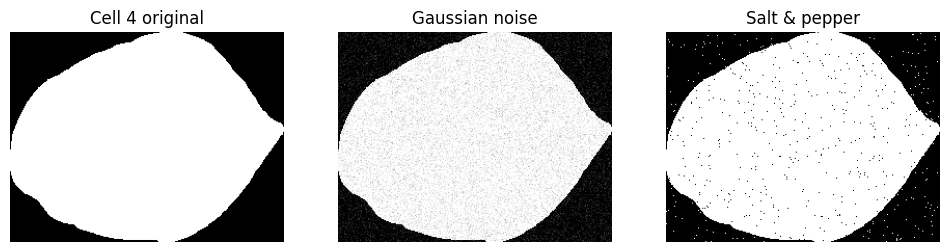

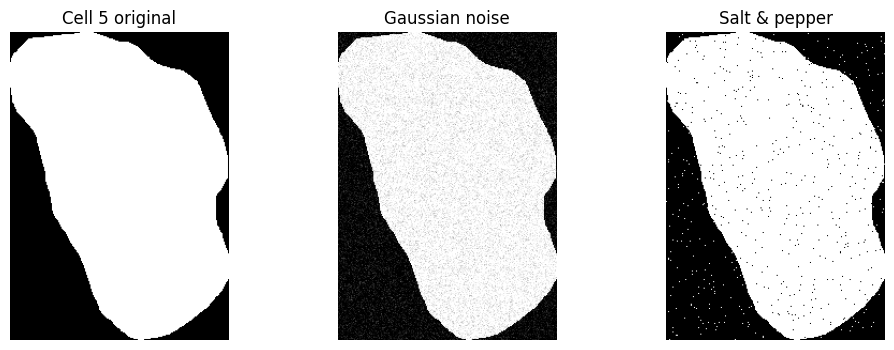

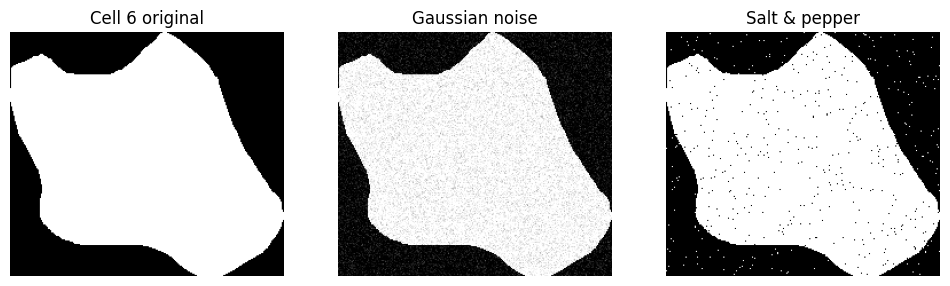

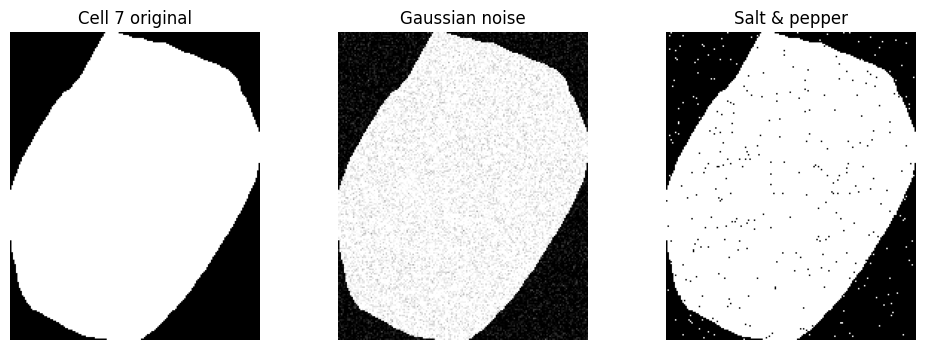

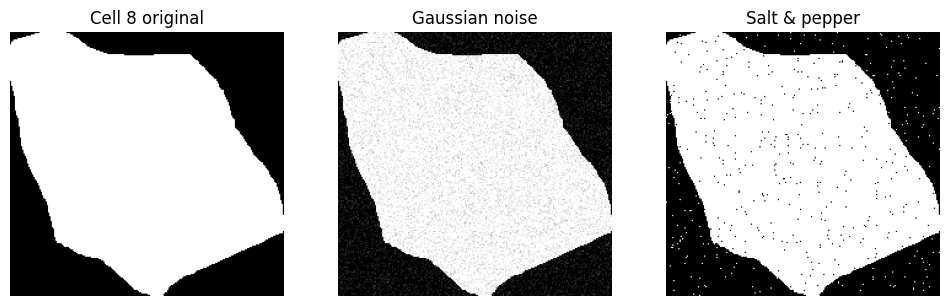

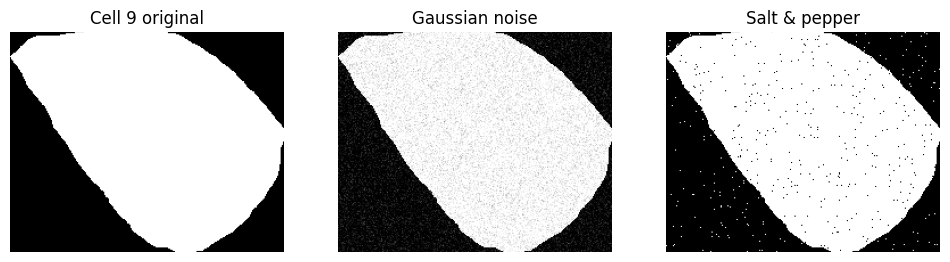

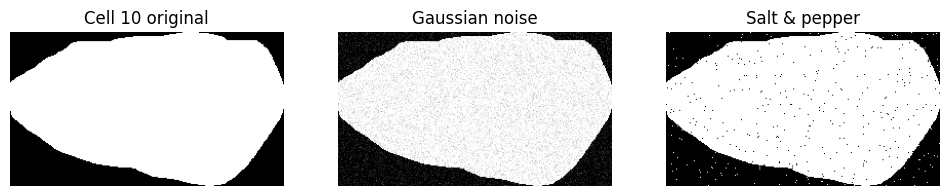

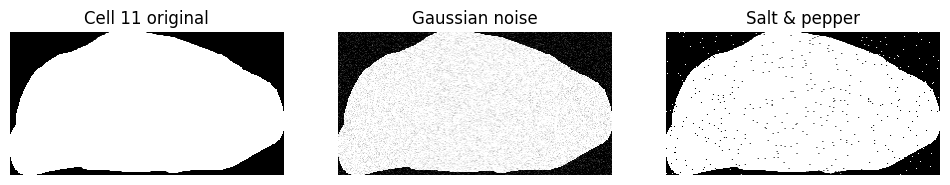

In [17]:
for cell_idx, cell_info in enumerate(all_cells_in_frame_no_1):
    cell_img = cell_info[0].astype(np.uint8)  # your cell image/mask at index 0
    gauss = add_gaussian_noise(cell_img, var=0.01)
    sp = add_salt_pepper(cell_img, amount=0.02)

    fig, ax = plt.subplots(1, 3, figsize=(12, 4))
    ax[0].imshow(cell_img, cmap='gray'); ax[0].set_title(f'Cell {cell_idx} original'); ax[0].axis('off')
    ax[1].imshow(gauss, cmap='gray'); ax[1].set_title('Gaussian noise'); ax[1].axis('off')
    ax[2].imshow(sp, cmap='gray'); ax[2].set_title('Salt & pepper'); ax[2].axis('off')
    plt.show()